In [1]:
# =============================================================================
# ML for the Quantified Self – Master Notebook
# Gym Movements Dataset: 2 participants × 3 activities × multiple sessions (LOSO evaluation)
# Models: RF, SVM, GBM | LSTM, CNN-LSTM, TCN
# =============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from Python.integrations import load_gym_dataset
from Python.plots import analyze_data_distribution
from Python.windows import create_adaptive_windows
from Python.feature_engineering import engineer_robust_features
from Python.training import train_with_validation

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# ── 1. LOAD GYM MOVEMENTS DATASET ────────────────────────────────────────────
print("Loading Gym Movements Dataset...")
raw_data = load_gym_dataset(Path("./Datasets/Gym Movements Dataset"))
print(f"\nTotal samples  : {len(raw_data):,}")
print(f"Participants   : {sorted(raw_data['participant'].unique())}")
print(f"Activities     : {sorted(raw_data['activity_label'].unique())}")
print(f"Sessions total : {raw_data['session'].nunique()}")
print(f"Sessions/person: {raw_data.groupby('participant')['session'].nunique().to_dict()}")
print(f"Columns        : {list(raw_data.columns)}")
raw_data.head(3)


Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 59,053
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 27
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity_label', 'participant', 'session', 'data_source']

Total samples  : 59,053
Participants   : ['imaan', 'richard']
Activities     : ['elliptical', 'lat_pull', 'row', 'threadmill']
Sessions total : 27
Sessions/person: {'imaan': 16, 'richard': 11}
Columns        : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity_label', 'participant', 'session', 'data_source']


,time,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z,activity_label,participant,session,data_source
0,0.000000,-0.688212,0.166774,-0.657767,0.013338,-0.156200,-1.396037,elliptical,imaan,0,original
1,0.409976,-0.068599,4.304119,-2.431066,0.439038,-0.056513,-1.396587,elliptical,imaan,0,original
2,0.419741,2.402801,0.533724,-2.446329,0.791037,0.185212,-0.250250,elliptical,imaan,0,original


In [2]:

# ── 2. MISSING VALUE HANDLING (Point 3) ──────────────────────────────────────
SENSOR_COLS = ["acc_x", "acc_y", "acc_z", "gyro_x", "gyro_y", "gyro_z"]

missing = raw_data[SENSOR_COLS].isnull().sum()
print("=== Missing Value Analysis ===")
print(f"Per-channel missing values:\n{missing.to_string()}")
total_missing = int(missing.sum())
print(f"\nTotal missing sensor readings: {total_missing}")

if total_missing > 0:
    print("\nApplying linear interpolation per (participant, session)...")
    raw_data[SENSOR_COLS] = (
        raw_data.groupby(["participant", "session"])[SENSOR_COLS]
        .transform(
            lambda g: g.interpolate(method="linear")
                       .ffill()
                       .bfill()
        )
    )
    remaining = int(raw_data[SENSOR_COLS].isnull().sum().sum())
    print(f"Remaining missing after interpolation: {remaining}")
else:
    print("\nNo missing values detected — dataset is complete.")


=== Missing Value Analysis ===
Per-channel missing values:
acc_x     0
acc_y     0
acc_z     0
gyro_x    0
gyro_y    0
gyro_z    0

Total missing sensor readings: 0

No missing values detected — dataset is complete.


=== Exploratory Data Analysis ===


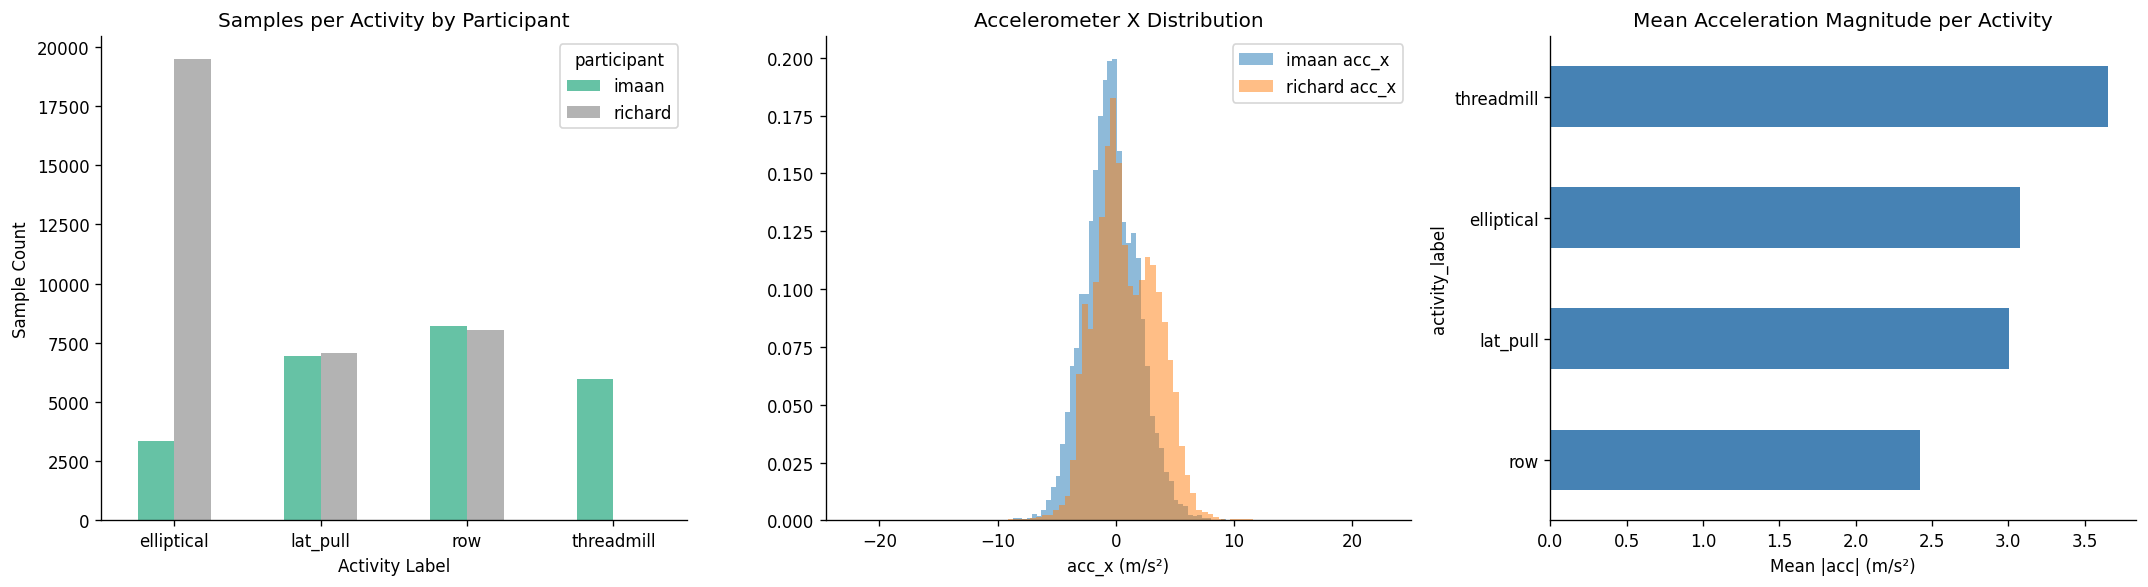


Class balance (samples per activity):
activity_label
elliptical    22826
lat_pull      14021
row           16222
threadmill     5984

Sensor statistics:
           acc_x      acc_y      acc_z     gyro_x     gyro_y     gyro_z
count  59053.000  59053.000  59053.000  59053.000  59053.000  59053.000
mean       0.347     -0.057     -0.068     -0.053      0.025      0.025
std        2.568      1.557      1.696      2.790      0.829      1.596
min      -22.293    -20.676    -13.147    -37.236     -9.393    -13.429
25%       -1.384     -0.878     -0.905     -0.400     -0.348     -0.786
50%        0.056     -0.002     -0.104     -0.022      0.005      0.049
75%        2.105      0.821      0.661      0.337      0.415      0.743
max       22.754     23.549     22.053     37.758      9.511     14.618


In [3]:

# ── 3. EXPLORATORY DATA ANALYSIS (Point 2) ───────────────────────────────────
print("=== Exploratory Data Analysis ===")

# Activity label distribution
if "activity_label" in raw_data.columns:
    act_col = "activity_label"
elif "activity" in raw_data.columns:
    act_col = "activity"
else:
    raise RuntimeError("No activity label column found in raw_data.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Samples per activity
act_counts = raw_data.groupby([act_col, "participant"]).size().unstack(fill_value=0)
act_counts.plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Samples per Activity by Participant")
axes[0].set_xlabel("Activity Label")
axes[0].set_ylabel("Sample Count")
axes[0].tick_params(axis="x", rotation=0)

# (b) Accelerometer distributions
for p, ls in zip(sorted(raw_data["participant"].unique()), ["-", "--"]):
    pdata = raw_data[raw_data["participant"] == p]
    axes[1].hist(pdata["acc_x"], bins=80, alpha=0.5, density=True, label=f"{p} acc_x", linestyle=ls)
axes[1].set_title("Accelerometer X Distribution")
axes[1].set_xlabel("acc_x (m/s²)")
axes[1].legend()

# (c) Gyroscope by activity (mean acc magnitude)
raw_data["acc_mag"] = np.sqrt(
    raw_data["acc_x"]**2 + raw_data["acc_y"]**2 + raw_data["acc_z"]**2
)
act_mag = raw_data.groupby(act_col)["acc_mag"].mean().sort_values()
act_mag.plot(kind="barh", ax=axes[2], color="steelblue")
axes[2].set_title("Mean Acceleration Magnitude per Activity")
axes[2].set_xlabel("Mean |acc| (m/s²)")

plt.tight_layout()
plt.savefig("./Plots/field_data_eda.png", dpi=150, bbox_inches="tight")
plt.show()

# Class balance report
print("\nClass balance (samples per activity):")
print(raw_data[act_col].value_counts().sort_index().to_string())
print(f"\nSensor statistics:\n{raw_data[SENSOR_COLS].describe().round(3).to_string()}")


In [4]:

# ── 4. WINDOWING & FEATURE ENGINEERING (Point 4) ─────────────────────────────
print("=== Windowing ===")
windowed_data = create_adaptive_windows(
    raw_data,
    min_window_size=64,
    preferred_window_size=128,   # 2.56 s @ 50 Hz
    overlap_ratio=0.5,
)

print("\n=== Feature Engineering ===")
features, labels, feature_names, metadata = engineer_robust_features(
    windowed_data, sampling_rate=50
)

print(f"\nFeature matrix shape: {features.shape}")
print(f"Label distribution  : {dict(zip(*np.unique(labels, return_counts=True)))}")

participants = np.array([m["participant"] for m in metadata])
print(f"Windows per participant: "
      f"{dict(zip(*np.unique(participants, return_counts=True)))}")


=== Windowing ===

Window creation summary:
  Full-size windows: 883
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 883

=== Feature Engineering ===
  Processing window 0/883...
  Processing window 100/883...
  Processing window 200/883...
  Processing window 300/883...
  Processing window 400/883...
  Processing window 500/883...
  Processing window 600/883...
  Processing window 700/883...
  Processing window 800/883...

Feature matrix shape: (883, 145)
Label distribution  : {np.str_('elliptical'): np.int64(346), np.str_('lat_pull'): np.int64(207), np.str_('row'): np.int64(242), np.str_('threadmill'): np.int64(88)}
Windows per participant: {np.str_('imaan'): np.int64(359), np.str_('richard'): np.int64(524)}


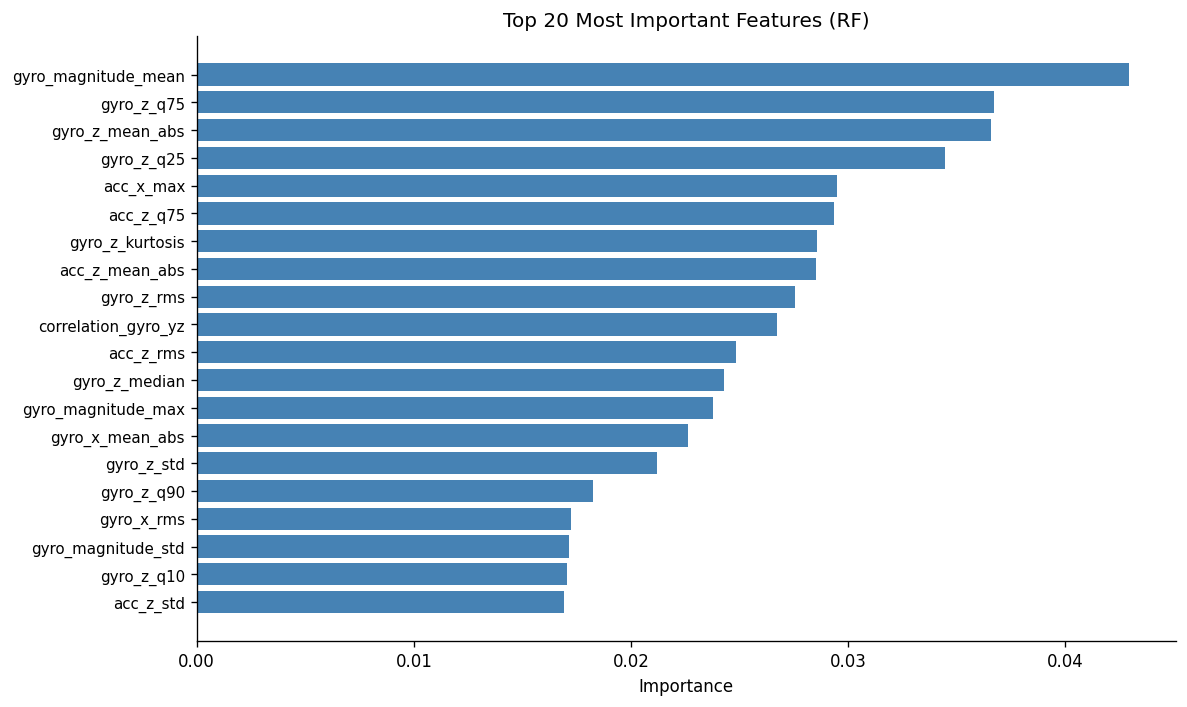

Top 5 features:
  1. gyro_magnitude_mean                      0.0429
  2. gyro_z_q75                               0.0367
  3. gyro_z_mean_abs                          0.0366
  4. gyro_z_q25                               0.0345
  5. acc_x_max                                0.0295


In [5]:

# ── 5. FEATURE IMPORTANCE (Point 4) ──────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Quick RF for feature importance (stratified, not the final eval split)
scaler_tmp = StandardScaler()
feat_scaled = scaler_tmp.fit_transform(features)

rf_tmp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_tmp.fit(feat_scaled, labels)

importances = rf_tmp.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    range(top_k),
    importances[top_idx][::-1],
    color="steelblue",
)
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_k} Most Important Features (RF)")
plt.tight_layout()
plt.savefig("./Plots/field_data_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Top 5 features:")
for rank, idx in enumerate(top_idx[:5], 1):
    print(f"  {rank}. {feature_names[idx]:40s} {importances[idx]:.4f}")



  RF – LOSO

=== Training [RF] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=359)

Test Accuracy [RF test=imaan]: 0.4930
              precision    recall  f1-score   support

  elliptical       0.23      0.85      0.36        46
    lat_pull       0.64      0.61      0.62       102
         row       0.84      0.62      0.71       123
  threadmill       0.00      0.00      0.00        88

    accuracy                           0.49       359
   macro avg       0.43      0.52      0.42       359
weighted avg       0.50      0.49      0.47       359



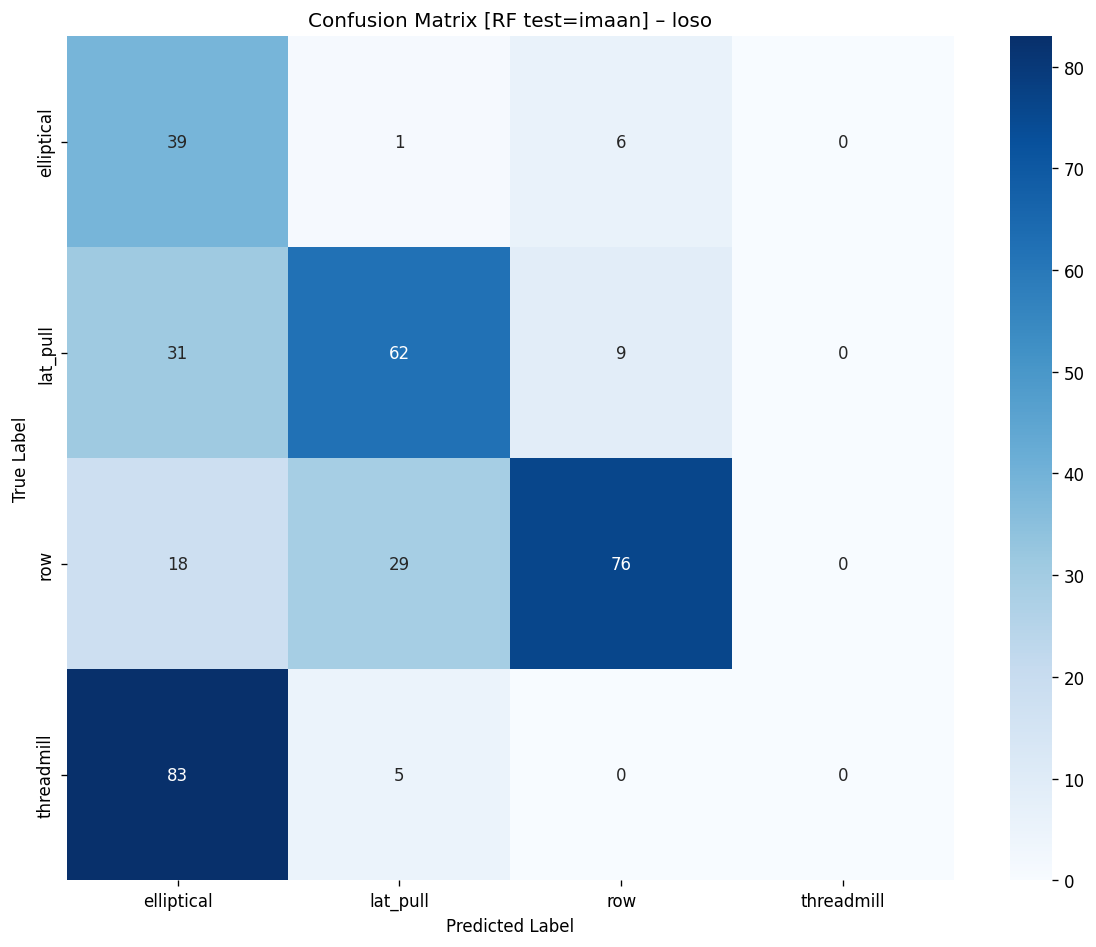


  LOSO fold: test=richard  (train=359, test=524)

Test Accuracy [RF test=richard]: 0.3607
              precision    recall  f1-score   support

  elliptical       1.00      0.23      0.38       300
    lat_pull       0.40      0.11      0.18       105
         row       0.25      0.90      0.39       119

    accuracy                           0.36       524
   macro avg       0.55      0.42      0.32       524
weighted avg       0.71      0.36      0.34       524



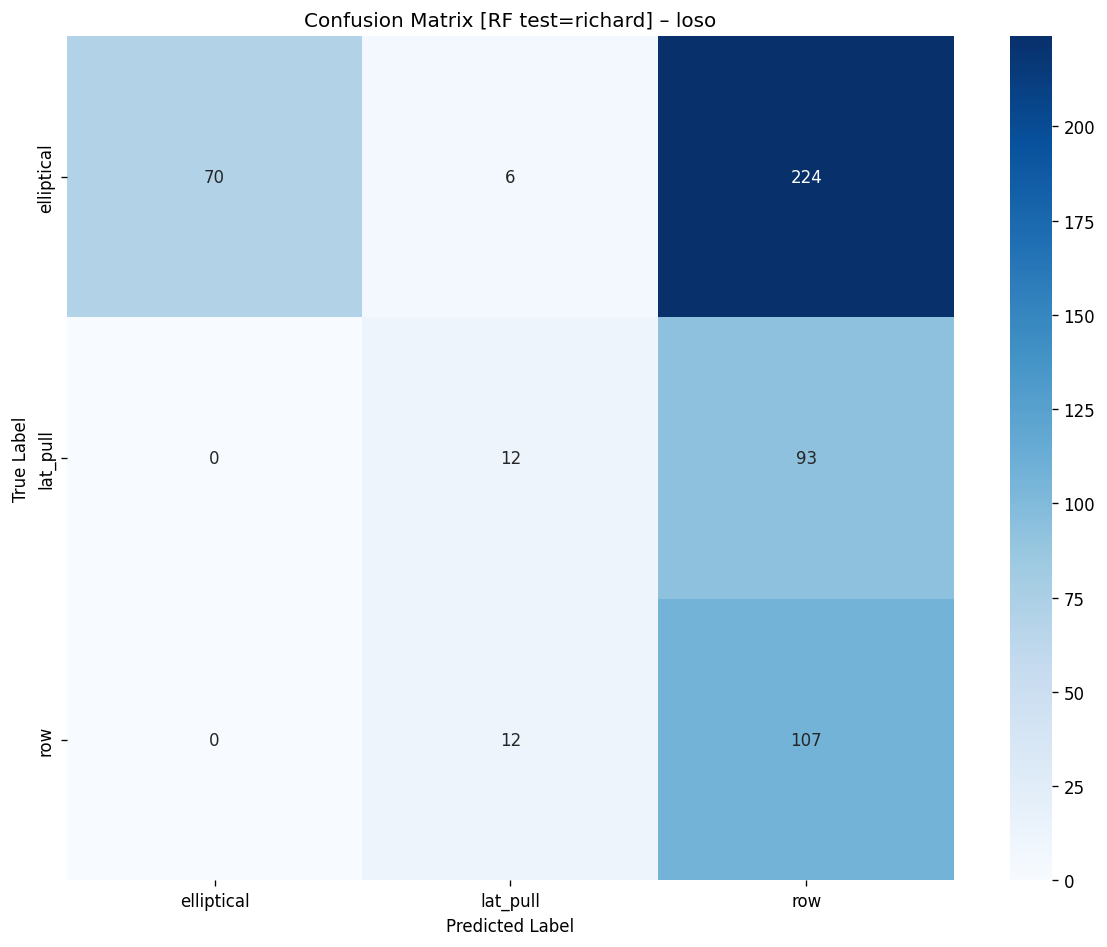


  LOSO Mean Accuracy (RF): 0.4269
  Per-fold: {'imaan': 0.49303621169916434, 'richard': 0.3606870229007634}

  SVM – LOSO

=== Training [SVM] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=359)

Test Accuracy [SVM test=imaan]: 0.2869
              precision    recall  f1-score   support

  elliptical       0.60      0.20      0.30        46
    lat_pull       0.39      0.81      0.53       102
         row       0.08      0.09      0.09       123
  threadmill       0.00      0.00      0.00        88

    accuracy                           0.29       359
   macro avg       0.27      0.27      0.23       359
weighted avg       0.22      0.29      0.22       359



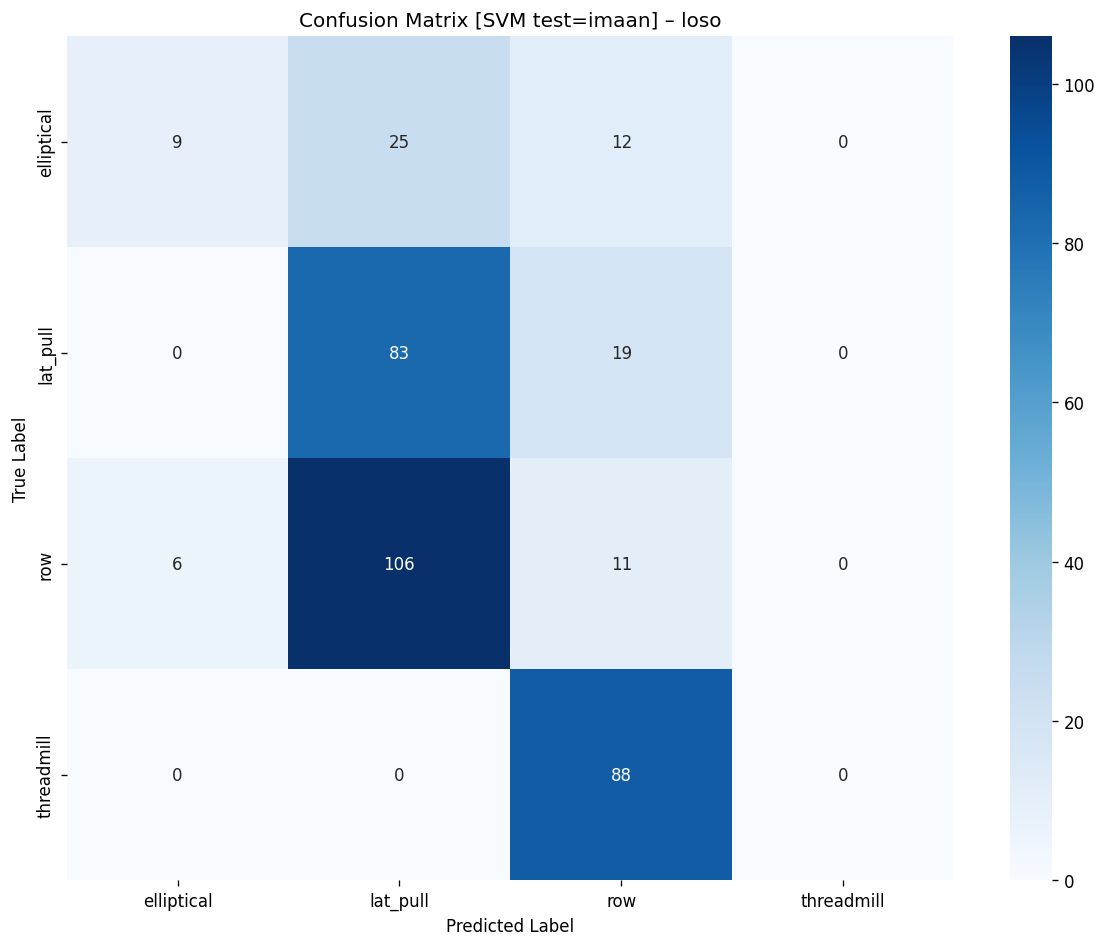


  LOSO fold: test=richard  (train=359, test=524)

Test Accuracy [SVM test=richard]: 0.2271
              precision    recall  f1-score   support

  elliptical       0.00      0.00      0.00       300
    lat_pull       0.56      0.05      0.09       105
         row       0.22      0.96      0.36       119

    accuracy                           0.23       524
   macro avg       0.26      0.34      0.15       524
weighted avg       0.16      0.23      0.10       524



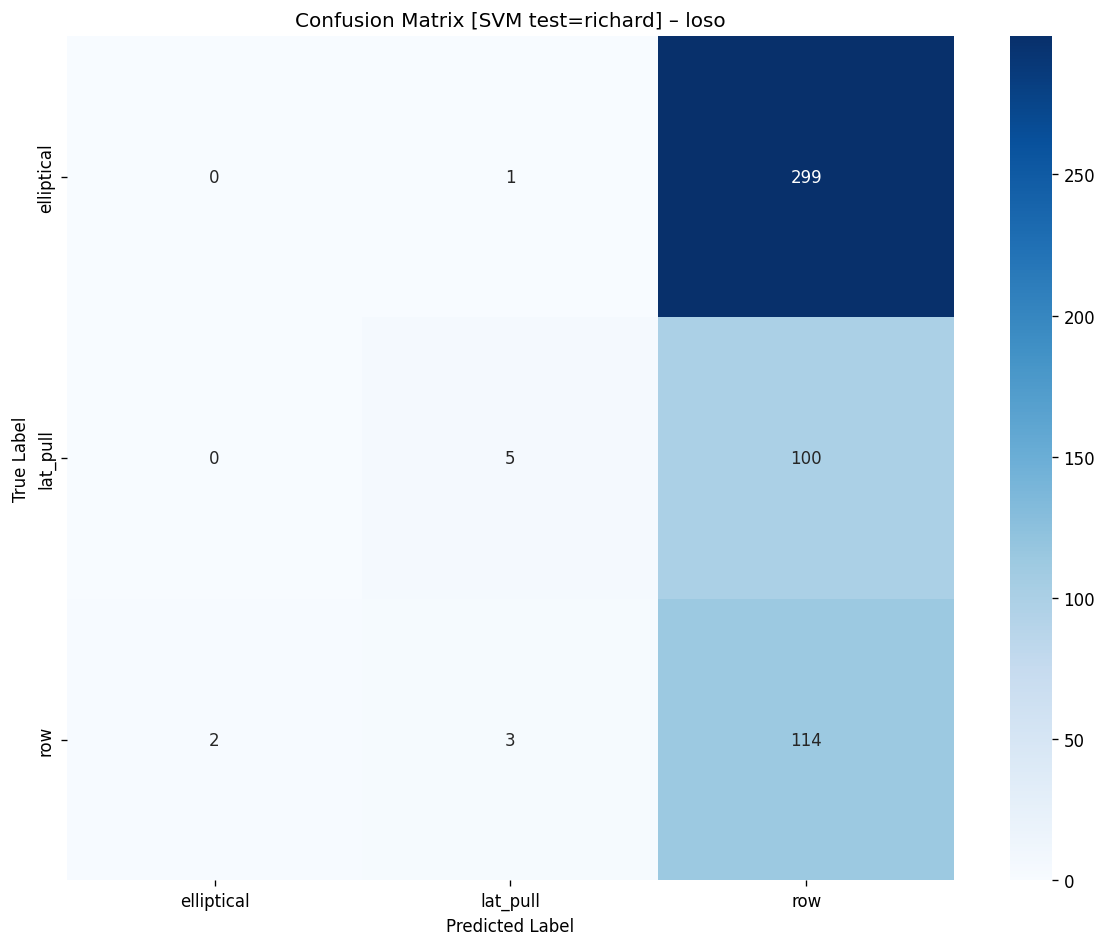


  LOSO Mean Accuracy (SVM): 0.2570
  Per-fold: {'imaan': 0.28690807799442897, 'richard': 0.22709923664122136}

  GBM – LOSO

=== Training [GBM] with [loso] validation ===

  LOSO fold: test=imaan  (train=524, test=359)

Test Accuracy [GBM test=imaan]: 0.6295
              precision    recall  f1-score   support

  elliptical       0.66      0.87      0.75        46
    lat_pull       0.47      0.70      0.56       102
         row       0.79      0.93      0.86       123
  threadmill       0.00      0.00      0.00        88

    accuracy                           0.63       359
   macro avg       0.48      0.63      0.54       359
weighted avg       0.49      0.63      0.55       359



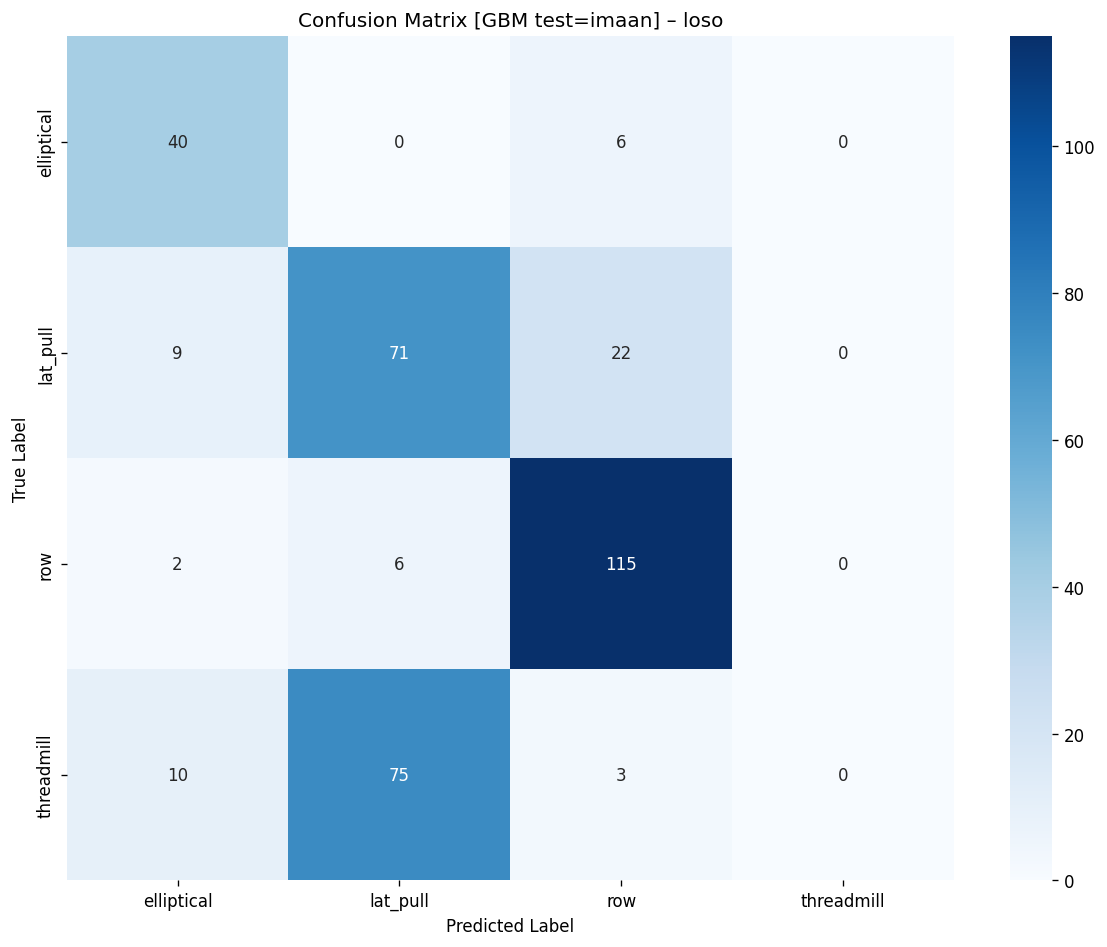


  LOSO fold: test=richard  (train=359, test=524)

Test Accuracy [GBM test=richard]: 0.2424
              precision    recall  f1-score   support

  elliptical       0.68      0.04      0.08       300
    lat_pull       0.11      0.05      0.07       105
         row       0.24      0.92      0.38       119

    accuracy                           0.24       524
   macro avg       0.34      0.34      0.17       524
weighted avg       0.47      0.24      0.15       524



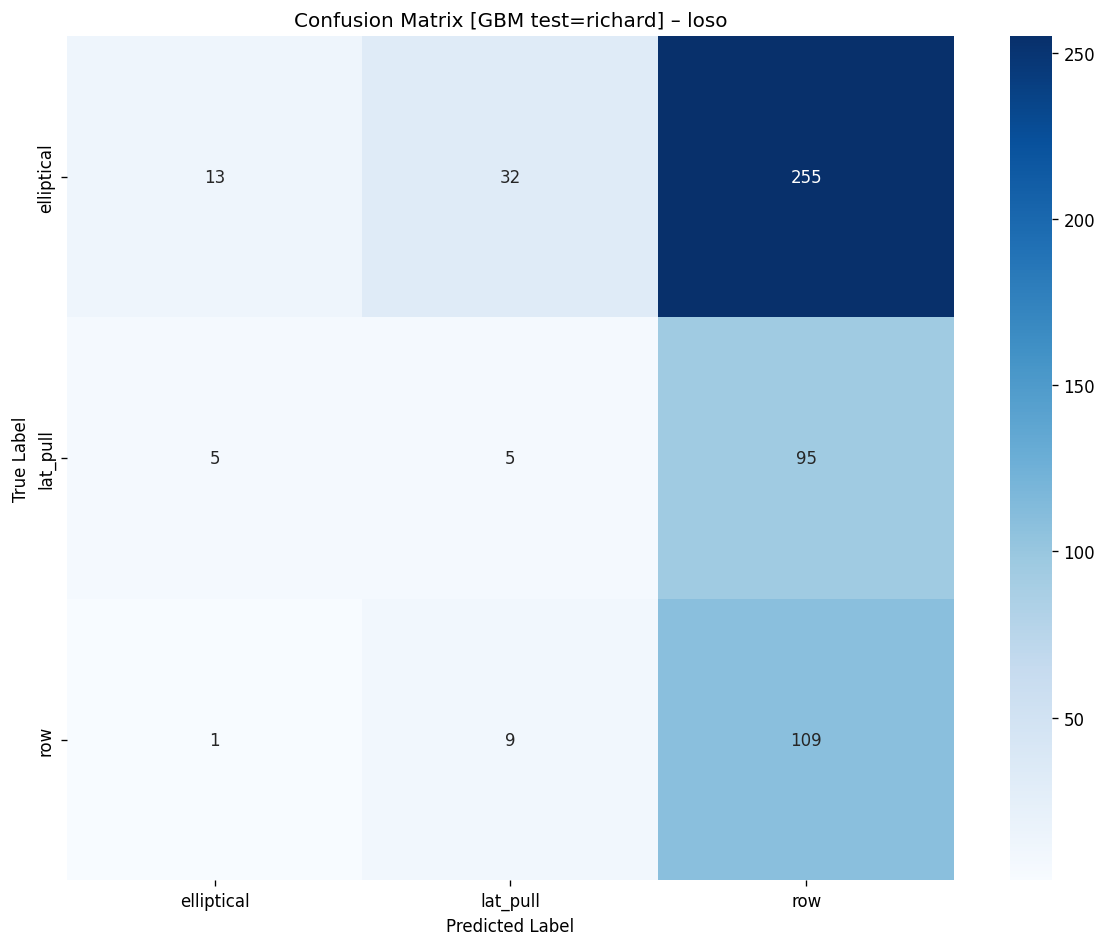


  LOSO Mean Accuracy (GBM): 0.4359
  Per-fold: {'imaan': 0.6295264623955432, 'richard': 0.24236641221374045}

=== Classical Model LOSO Summary ===
  RF  : mean LOSO accuracy = 0.4269  | per-fold = {'imaan': 0.49303621169916434, 'richard': 0.3606870229007634}
  SVM : mean LOSO accuracy = 0.2570  | per-fold = {'imaan': 0.28690807799442897, 'richard': 0.22709923664122136}
  GBM : mean LOSO accuracy = 0.4359  | per-fold = {'imaan': 0.6295264623955432, 'richard': 0.24236641221374045}


In [6]:

# ── 6. CLASSICAL ML – LOSO EVALUATION (Point 5) ──────────────────────────────
# Evaluation split: Leave-One-Subject-Out
# Train on participant A → test on participant B, and vice versa.
# This measures generalisation to an unseen person, as required by the brief.

classical_results = {}
classical_models = {}

for model_type in ["rf", "svm", "gbm"]:
    print(f"\n{'='*60}")
    print(f"  {model_type.upper()} – LOSO")
    print(f"{'='*60}")
    trained_model, trained_scaler, res = train_with_validation(
        features, labels, feature_names, metadata,
        validation_strategy="loso",
        model_type=model_type,
    )
    classical_results[model_type] = res
    classical_models[model_type] = (trained_model, trained_scaler)

rf_model = classical_models["rf"][0]

print("\n=== Classical Model LOSO Summary ===")
for mt, res in classical_results.items():
    print(f"  {mt.upper():4s}: mean LOSO accuracy = {res['mean_accuracy']:.4f}  "
          f"| per-fold = {res['per_fold_accuracy']}")



Gym Movements Deep Learning Pipeline (LOSO Evaluation)

Loading Gym Movements Dataset...
Gym Movements Dataset loaded:
  Total samples : 59,053
  Participants  : ['imaan', 'richard']
  Activities    : ['elliptical', 'lat_pull', 'row', 'threadmill']
  Sessions      : 27
  Columns       : ['time', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'activity_label', 'participant', 'session', 'data_source']
Total samples: 59053
Participants: ['imaan', 'richard']
Activities: ['elliptical', 'lat_pull', 'row', 'threadmill']

=== Missing Value Analysis ===
Missing values per channel:
acc_x     0
acc_y     0
acc_z     0
gyro_x    0
gyro_y    0
gyro_z    0
No missing values found.

Creating adaptive windows...

Window creation summary:
  Full-size windows: 883
  Adaptive windows: 0
  Rejected segments: 0
  Total windows: 883

Preparing raw sequences for DL models...
Sequences shape: (883, 128, 6)

Starting LOSO evaluation (TCN, LSTM, CNN-LSTM)...

LOSO participants: ['imaan', 'richard']
C

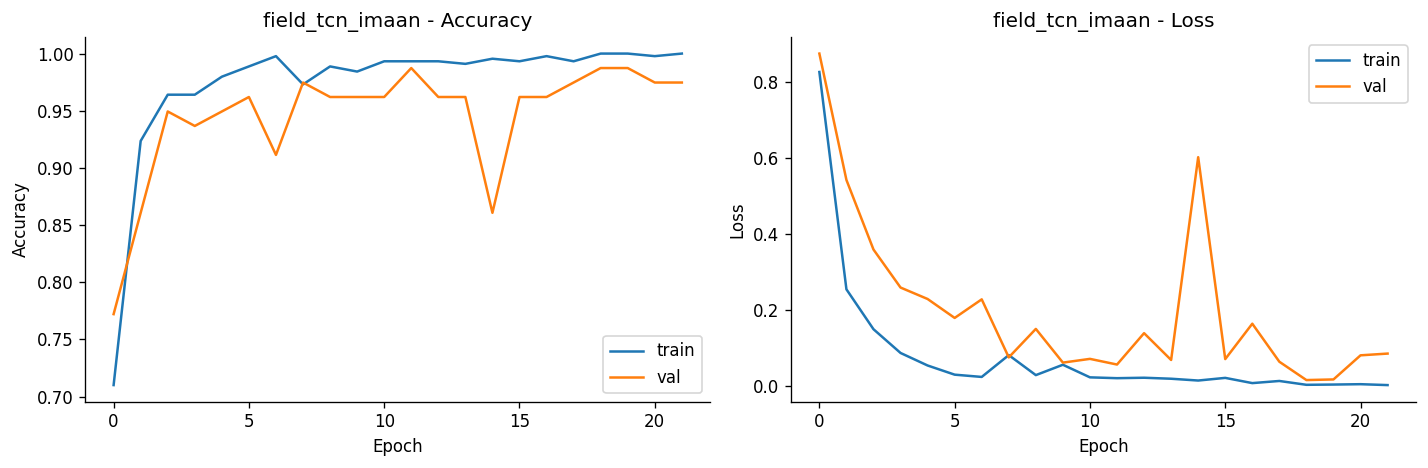


Training LSTM (test=imaan)...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.5101 - loss: 1.2406 - val_accuracy: 0.6456 - val_loss: 0.9880 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7213 - loss: 0.7843 - val_accuracy: 0.7342 - val_loss: 0.5620 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7708 - loss: 0.4718 - val_accuracy: 0.7595 - val_loss: 0.4356 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7955 - loss: 0.4154 - val_accuracy: 0.7848 - val_loss: 0.3777 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7978 - loss: 0.3664 - val_accuracy: 0.7468 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8067 - loss: 0.3501 - val_accuracy: 0.7722 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 

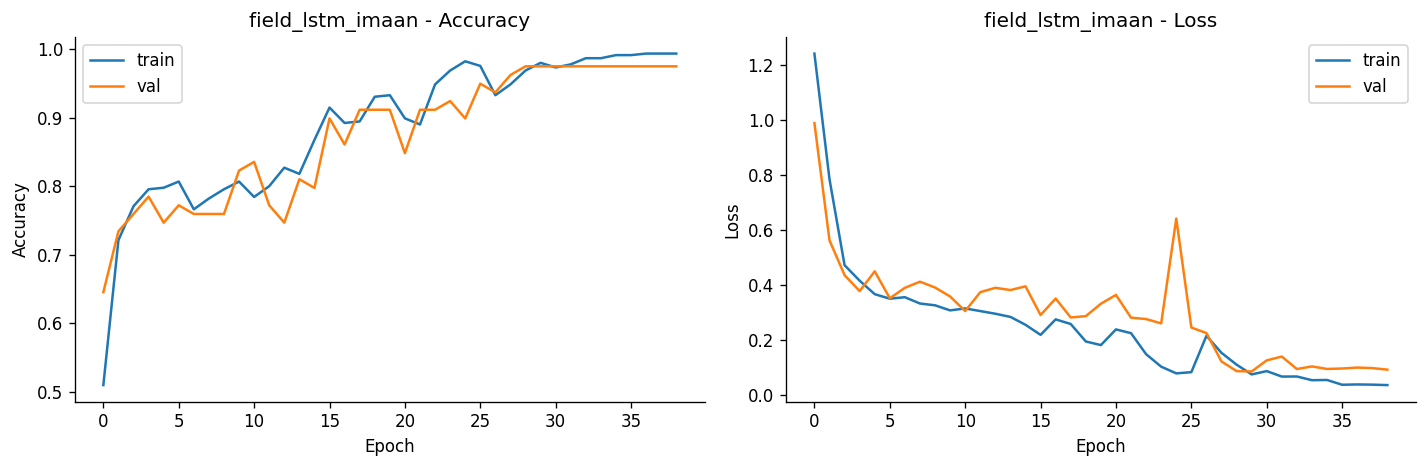


Training CNN_LSTM (test=imaan)...
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5303 - loss: 1.2102 - val_accuracy: 0.5696 - val_loss: 1.1605 - learning_rate: 0.0010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7461 - loss: 0.7457 - val_accuracy: 0.5823 - val_loss: 1.1550 - learning_rate: 0.0010
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8225 - loss: 0.4485 - val_accuracy: 0.5696 - val_loss: 2.0631 - learning_rate: 0.0010
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8764 - loss: 0.3203 - val_accuracy: 0.7595 - val_loss: 0.9457 - learning_rate: 0.0010
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9011 - loss: 0.2608 - val_accuracy: 0.8228 - val_loss: 0.7952 - learning_rate: 0.0010
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9775 - loss: 0.1074 - val_accuracy: 0.8228 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accura

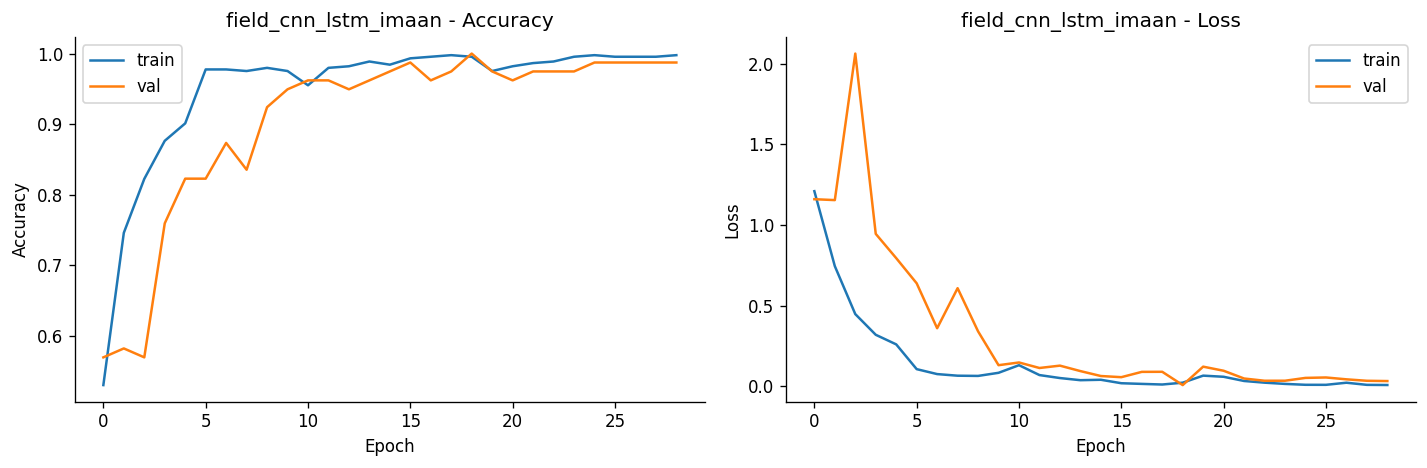


LOSO fold: TEST participant = richard
Train samples: 359, Test samples: 524

Training TCN (test=richard)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.7770 - loss: 0.6194 - val_accuracy: 0.3704 - val_loss: 1.0609 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9607 - loss: 0.1530 - val_accuracy: 0.6481 - val_loss: 0.7456 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9770 - loss: 0.0945 - val_accuracy: 0.8333 - val_loss: 0.4695 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9902 - loss: 0.0411 - val_accuracy: 0.9815 - val_loss: 0.2731 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9967 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 0.1304 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9902 - loss: 0.0263 - val_accuracy: 1.0000 - val_loss: 0.0618 - learnin

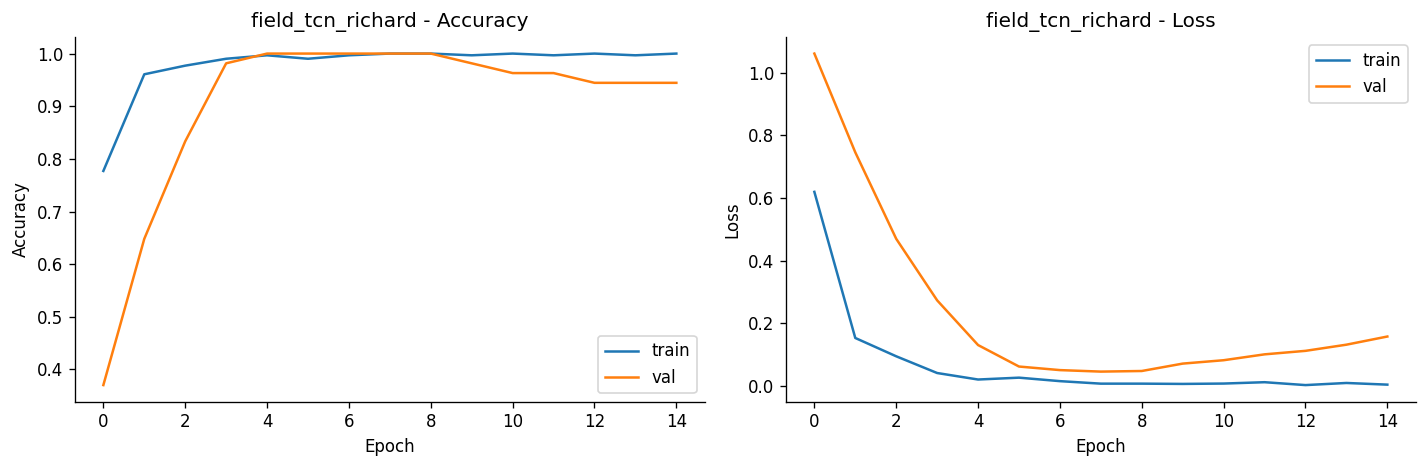


Training LSTM (test=richard)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.3770 - loss: 1.3275 - val_accuracy: 0.6296 - val_loss: 1.2280 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.6033 - loss: 1.1453 - val_accuracy: 0.7407 - val_loss: 0.9753 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7672 - loss: 0.8194 - val_accuracy: 0.8889 - val_loss: 0.5551 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8885 - loss: 0.5151 - val_accuracy: 0.8889 - val_loss: 0.3802 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.9148 - loss: 0.3341 - val_accuracy: 0.9444 - val_loss: 0.2155 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9377 - loss: 0.2911 - val_accuracy: 0.8889 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy

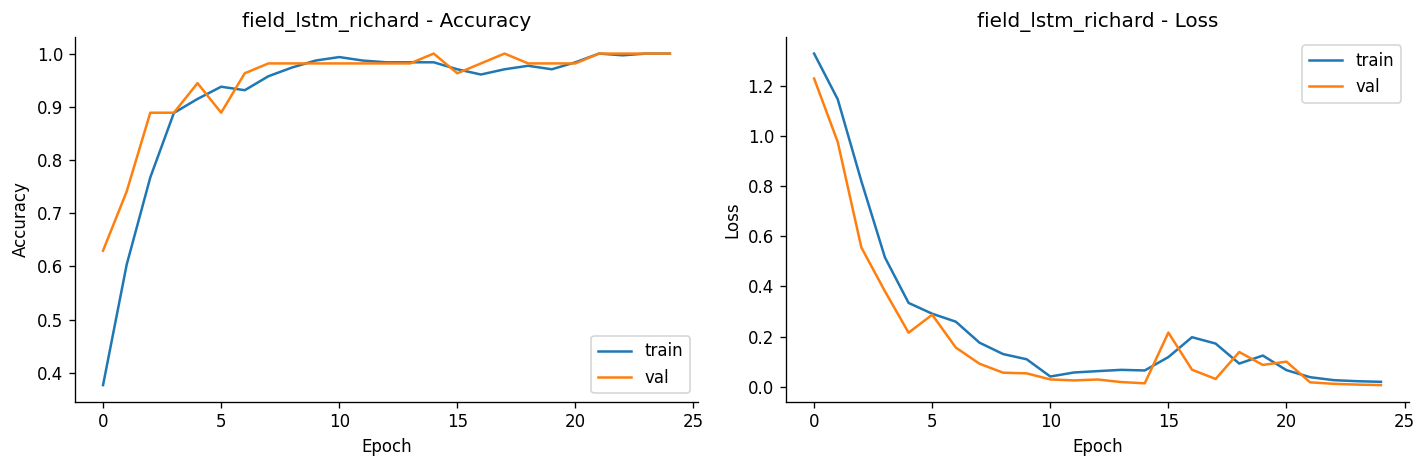


Training CNN_LSTM (test=richard)...
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4623 - loss: 1.2706 - val_accuracy: 0.3333 - val_loss: 1.2964 - learning_rate: 0.0010
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7475 - loss: 0.9908 - val_accuracy: 0.4444 - val_loss: 1.2079 - learning_rate: 0.0010
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8131 - loss: 0.7471 - val_accuracy: 0.5000 - val_loss: 1.0730 - learning_rate: 0.0010
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8787 - loss: 0.5256 - val_accuracy: 0.6852 - val_loss: 0.8349 - learning_rate: 0.0010
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9443 - loss: 0.3026 - val_accuracy: 0.9444 - val_loss: 0.2557 - learning_rate: 0.0010
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9541 - loss: 0.1820 - val_accuracy: 0.9444 - val_loss: 0.1650 - learning_rate: 0.0010
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accu

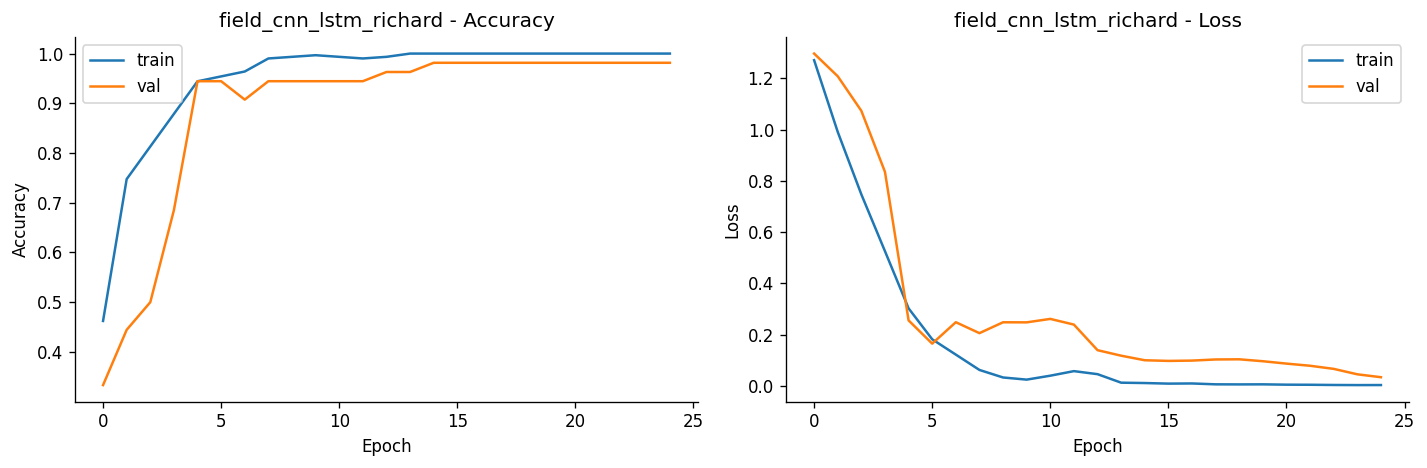


LOSO Summary
  TCN       : imaan=0.3621, richard=0.2424  ->  Mean = 0.3022
  LSTM      : imaan=0.3900, richard=0.2156  ->  Mean = 0.3028
  CNN_LSTM  : imaan=0.4457, richard=0.2405  ->  Mean = 0.3431


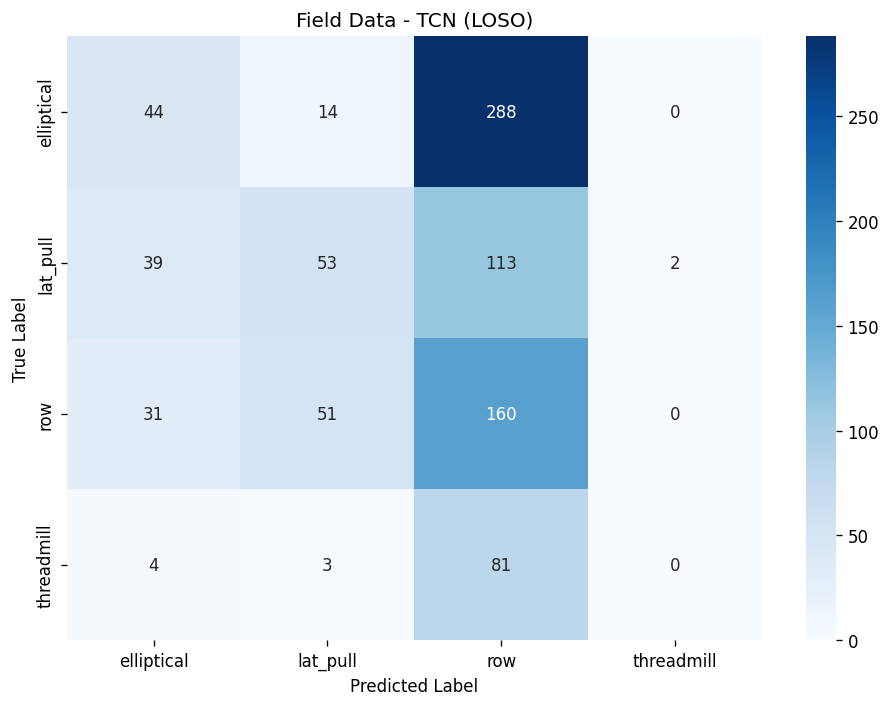

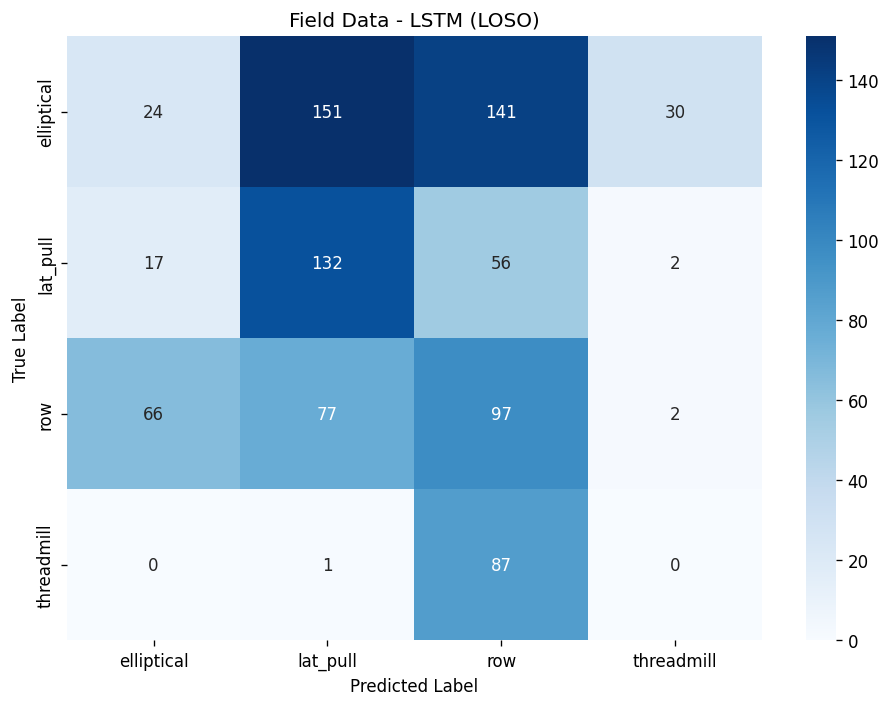

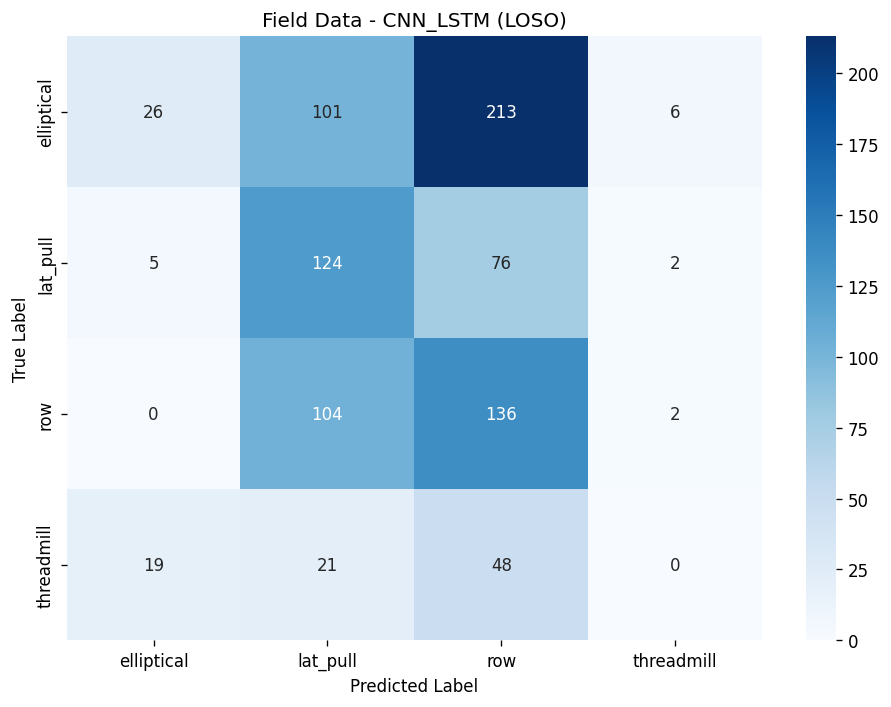


Results saved to: ./Models/Gym Models/dl_loso_results_20260605_143839.json

Model Comparison (mean LOSO accuracy)
  TCN         : 0.3022
  LSTM        : 0.3028
  CNN_LSTM    : 0.3431

  (RF model from cell 1 is available — re-run training.py with LOSO for RF accuracy)

Deep Learning Pipeline Complete

=== Deep Learning LOSO Summary ===
  TCN       : mean LOSO accuracy = 0.3022
  LSTM      : mean LOSO accuracy = 0.3028
  CNN_LSTM  : mean LOSO accuracy = 0.3431


In [7]:
# ── 7. DEEP LEARNING – LOSO EVALUATION (Point 6) ─────────────────────────────
# TCN, LSTM, CNN-LSTM trained on raw sequences with LOSO split.
# Uses Python.posthoc.get_training_summary which:
#   - reloads raw data
#   - handles missing values
#   - creates windows and sequences
#   - runs LOSO evaluation for all three DL models
#   - saves results + plots

from Python.posthoc import get_training_summary

dl_results, dl_summary = get_training_summary(rf_model=rf_model)

print("\n=== Deep Learning LOSO Summary ===")
for mt, s in dl_summary.items():
    print(f"  {mt.upper():10s}: mean LOSO accuracy = {s['mean']:.4f}")


=== Per-Activity Classification Report (RF LOSO, all folds) ===
              precision    recall  f1-score   support

  elliptical       0.45      0.32      0.37       346
    lat_pull       0.58      0.36      0.44       207
         row       0.36      0.76      0.48       242
  threadmill       0.00      0.00      0.00        88

    accuracy                           0.41       883
   macro avg       0.35      0.36      0.32       883
weighted avg       0.41      0.41      0.38       883



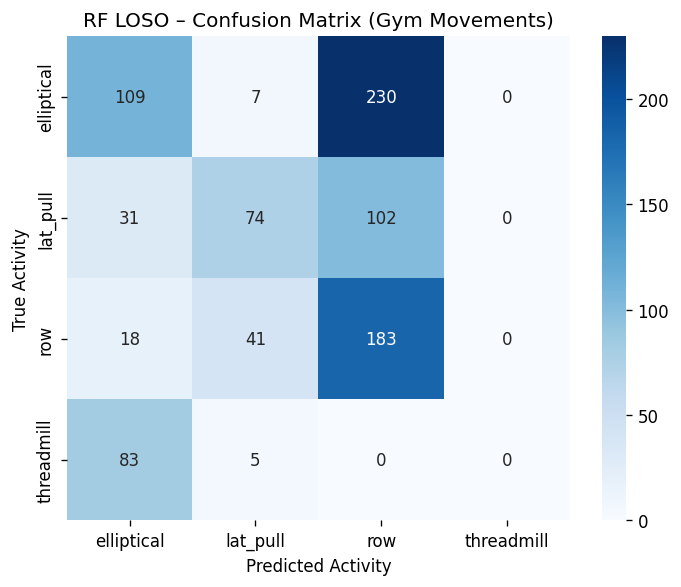


Samples per activity (windows):
  elliptical     : 346
  lat_pull       : 207
  row            : 242
  threadmill     : 88


In [8]:
# ── 8. PER-ACTIVITY ACCURACY BREAKDOWN ───────────────────────────────────────
# Analyse which gym movement is hardest to classify by looking at per-class
# precision / recall from the aggregated LOSO predictions of the best classical model.

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Use the RF LOSO predictions (all folds combined)
rf_res = classical_results["rf"]
y_true_all = np.array(rf_res["all_true"])
y_pred_all = np.array(rf_res["all_pred"])
activities = sorted(set(y_true_all))

print("=== Per-Activity Classification Report (RF LOSO, all folds) ===")
print(classification_report(y_true_all, y_pred_all, target_names=activities, zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true_all, y_pred_all, labels=activities)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=activities, yticklabels=activities, ax=ax,
)
ax.set_title("RF LOSO – Confusion Matrix (Gym Movements)")
ax.set_ylabel("True Activity")
ax.set_xlabel("Predicted Activity")
plt.tight_layout()
plt.savefig("./Plots/gym_rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Per-activity sample counts
print("\nSamples per activity (windows):")
unique, counts = np.unique(y_true_all, return_counts=True)
for act, cnt in zip(unique, counts):
    print(f"  {act:<15s}: {cnt}")


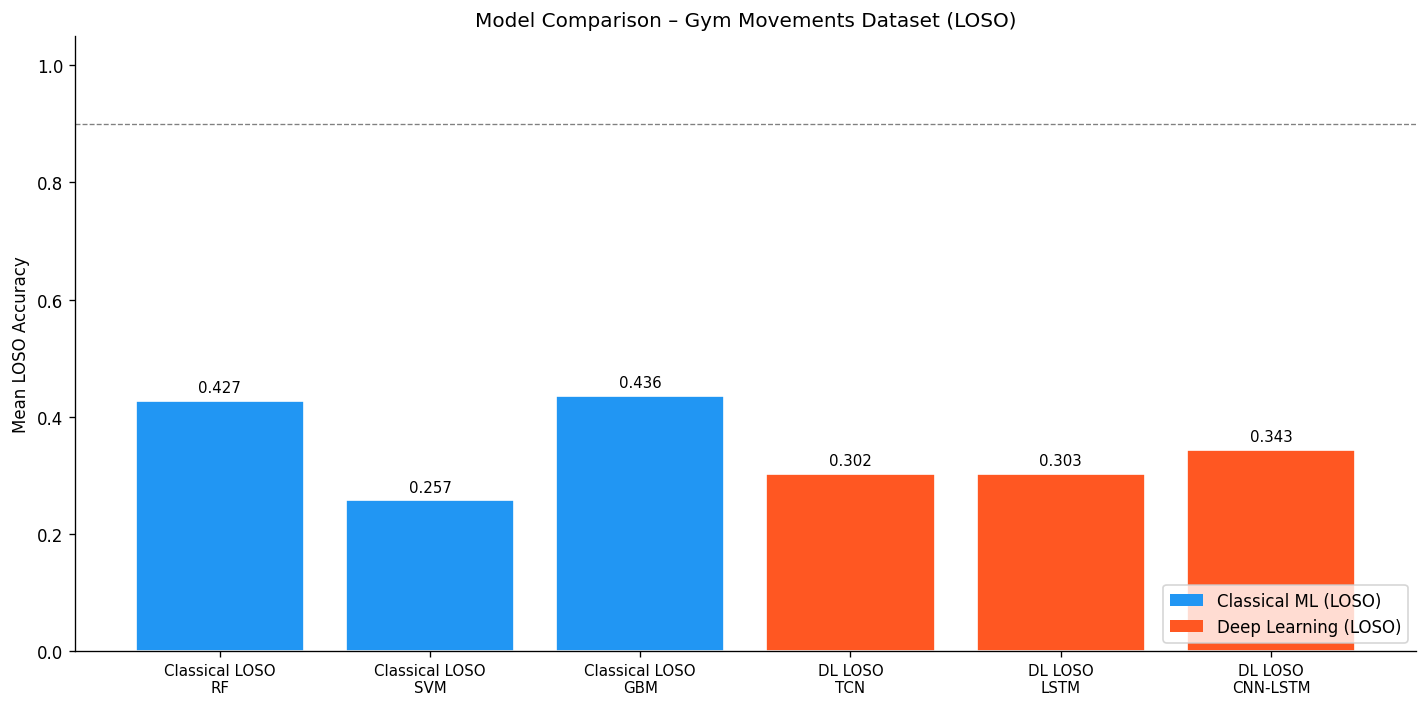


=== Final Results Table ===
Model                            Mean LOSO Accuracy
----------------------------------------------------
Classical LOSO – RF                                    0.4269
Classical LOSO – SVM                                   0.2570
Classical LOSO – GBM                                   0.4359
DL LOSO – TCN                                          0.3022
DL LOSO – LSTM                                         0.3028
DL LOSO – CNN-LSTM                                     0.3431


In [9]:
# ── 9. MODEL COMPARISON VISUALISATION ────────────────────────────────────────

# Collect results
all_accs = {}

# Classical LOSO
for mt, res in classical_results.items():
    all_accs[f"Classical LOSO\n{mt.upper()}"] = res["mean_accuracy"]

# Deep learning LOSO
for mt, s in dl_summary.items():
    label = {"tcn": "TCN", "lstm": "LSTM", "cnn_lstm": "CNN-LSTM"}.get(mt, mt.upper())
    all_accs[f"DL LOSO\n{label}"] = s["mean"]

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = (
    ["#2196F3"] * len(classical_results)
    + ["#FF5722"] * len(dl_summary)
)
bars = ax.bar(list(all_accs.keys()), list(all_accs.values()), color=colors, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Mean LOSO Accuracy")
ax.set_title("Model Comparison – Gym Movements Dataset (LOSO)")
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, label="0.90 reference")

for bar, val in zip(bars, all_accs.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9,
    )

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", label="Classical ML (LOSO)"),
    Patch(facecolor="#FF5722", label="Deep Learning (LOSO)"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.xticks(rotation=0, ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./Plots/gym_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Final Results Table ===")
print(f"{'Model':<30} {'Mean LOSO Accuracy':>20}")
print("-" * 52)
for name, acc in all_accs.items():
    label = name.replace("\n", " – ")
    print(f"{label:<50} {acc:>10.4f}")
